--- Generating Comparison Chart: Points/Scatter Version ---
Success! Point-based comparison chart saved at: ..\figuras\figure-hindcasting-validation-points.pdf


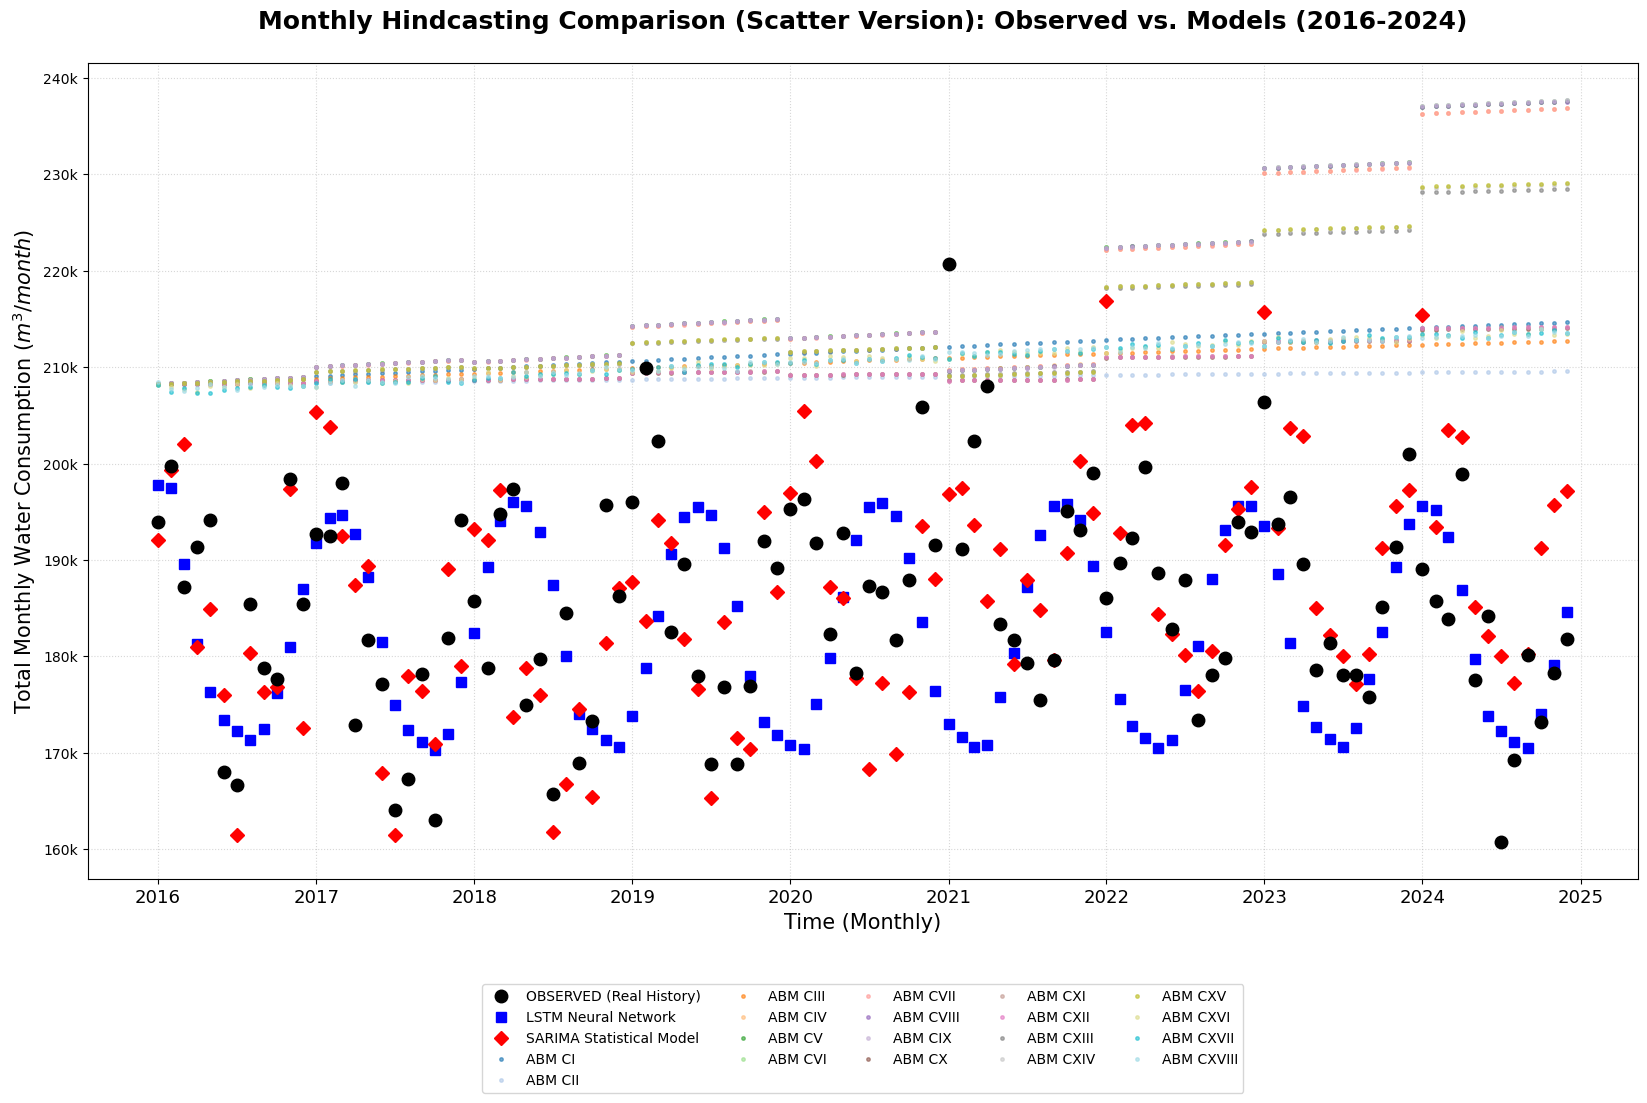

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import numpy as np
import os

# ==========================================
# 1. Configurations and Paths
# ==========================================
BASE_PATH = '..' 

REAL_FILE = 'Tabela_consumo_real_historico_2016_2025.csv'
SIM_FILE = 'simulacao_hindcasting_2016_2025.csv'
LSTM_FILE = 'previsao_consumo_2016_2025.csv' 
SARIMA_FILE = 'previsao_consumo_sarima_2016_2025.csv'

OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
# Novo nome para diferenciar o arquivo
OUTPUT_FIG_POINTS = 'figure-hindcasting-validation-points.pdf'

INPUT_DIR_INCLUDES = os.path.join(BASE_PATH, 'includes')
INPUT_DIR_RESULTS = os.path.join(BASE_PATH, 'resultados')
INPUT_DIR_IA = os.path.join(BASE_PATH, 'modelos IA')

def main():
    print("--- Generating Comparison Chart: Points/Scatter Version ---")

    # ==========================================
    # 2. Data Loading (Mantido conforme original)
    # ==========================================
    path_real = os.path.join(INPUT_DIR_INCLUDES, REAL_FILE)
    df_real = pd.read_csv(path_real, sep=';', decimal='.')
    df_real['Date'] = pd.to_datetime(df_real['AM_REFERENCIA'].astype(str) + '01', format='%Y%m%d')
    df_real.rename(columns={'real_total_consumption': 'Real'}, inplace=True)

    path_sim = os.path.join(INPUT_DIR_RESULTS, SIM_FILE)
    df_sim = pd.read_csv(path_sim, sep=';', decimal=',')
    if 'Ano' in df_sim.columns and 'Mes' in df_sim.columns:
        df_sim['Date'] = pd.to_datetime(df_sim['Ano'].astype(str) + '-' + df_sim['Mes'].astype(str) + '-01')
    
    scenario_cols = [c for c in df_sim.columns if c not in ['Mes', 'Ano', 'Mes_Ano', 'Date', 'AM_REFERENCIA']]

    path_lstm = os.path.join(INPUT_DIR_IA, LSTM_FILE) 
    df_lstm = pd.read_csv(path_lstm, sep=';') if os.path.exists(path_lstm) else None
    if df_lstm is not None: df_lstm['Date'] = pd.to_datetime(df_lstm['Mes_Referencia'])

    path_sarima = os.path.join(INPUT_DIR_IA, SARIMA_FILE)
    df_sarima = pd.read_csv(path_sarima) if os.path.exists(path_sarima) else None
    if df_sarima is not None: df_sarima['Date'] = pd.to_datetime(df_sarima['Date'])

    # ==========================================
    # 3. Plotting (Updated to Points)
    # ==========================================
    fig, ax = plt.subplots(figsize=(20, 12))

    # --- A. Plotting 18 ABM Scenarios (Highlighted Points) ---
    # Alpha aumentado para 0.6 para realçar e linestyle='None' para ser apenas pontos
    colors = plt.cm.tab20(np.linspace(0, 1, len(scenario_cols)))
    for idx, col in enumerate(scenario_cols):
        scen_id = col.split('_')[0]
        ax.plot(df_sim['Date'], df_sim[col], color=colors[idx],
                marker='.', linestyle='None', alpha=0.6, markersize=5, label=f"ABM {scen_id}")

    # --- B. Plotting LSTM Prediction (Blue Squares) ---
    if df_lstm is not None:
        ax.plot(df_lstm['Date'], df_lstm['Previsao_Consumo'], label='LSTM Neural Network', 
                color='blue', marker='s', linestyle='None', markersize=7, zorder=25)

    # --- C. Plotting SARIMA Prediction (Red Diamonds) ---
    if df_sarima is not None:
        ax.plot(df_sarima['Date'], df_sarima['Projected_Consumption'], label='SARIMA Statistical Model', 
                color='red', marker='D', linestyle='None', markersize=7, zorder=26)

    # --- D. Plotting Historical Ground Truth (Black Circles) ---
    ax.plot(df_real['Date'], df_real['Real'], label='OBSERVED (Real History)', color='black',
            marker='o', linestyle='None', markersize=9, zorder=30)

    # ==========================================
    # 4. Final Formatting
    # ==========================================
    ax.set_ylabel('Total Monthly Water Consumption ($m^3/month$)', fontsize=15)
    ax.set_xlabel('Time (Monthly)', fontsize=15)
    
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=0, fontsize=13)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
    
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.title('Monthly Hindcasting Comparison (Scatter Version): Observed vs. Models (2016-2025)', 
              fontsize=18, fontweight='bold', pad=25)

    # Legend adjust
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    main_keys = ['OBSERVED (Real History)', 'LSTM Neural Network', 'SARIMA Statistical Model']
    other_keys = [k for k in by_label.keys() if k not in main_keys]
    sorted_keys = main_keys + other_keys

    plt.legend([by_label[k] for k in sorted_keys], sorted_keys, 
               loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=5, 
               fontsize=10, frameon=True)
    
    plt.subplots_adjust(bottom=0.20)

    # Save to PDF
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    save_path = os.path.join(OUTPUT_DIR, OUTPUT_FIG_POINTS)
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    
    print(f"Success! Point-based comparison chart saved at: {save_path}")
    plt.show()

if __name__ == "__main__":
    main()